
## Machine Learning Model Development

## Supervised Learning  => Curso databricks

### 1.1a training Classification Models


### Visualizing Feature Importance

To wrap up our linear regression analysis, we will plot the sized coefficients. This bar chart visually confirms how much each standardized feature influences the `median_house_value`. Positive bars increase the predicted price, while negative bars decrease it.

# 1.1b - Training Classification Models

## Training Regression and Classification Models

In this demo, we will explore the process of training classification models using the `sklearn` API. In addition to fitting the model, we will inspect the model details and show how a decision tree is constructed.

For this classification project, we will be using the **Diabetes Classification Dataset** (`diabete.csv`).

### Learning Objectives:

By the end of this demo, you will be able to:

* Fit a classification model on modeling data using the sklearn API.
* Fit a decision tree model using sklearn API and training data.
* Visualize a sklearn tree's split points.
* Identify which metrics are tracked by MLflow.

---

## Prepare Dataset

Before training any machine learning models, it's crucial to prepare the dataset. In this section, we cover the steps to load, clean, and preprocess the data, ensuring it's in a suitable format for model training.

## Load Dataset

In this section, we aim to optimize the process of loading the dataset. Instead of using a feature table store, we will load the data directly from our public repository, clean any unnecessary indicators, and cast features into appropriate formats.

https://github.com/GRicciardi00/Kaggle-Diabetes-classification/blob/main/diabete.csv

In [1]:
import pandas as pd

# URL do arquivo bruto (raw) do GitHub com o Diabetes dataset
url_diabetes = "https://raw.githubusercontent.com/GRicciardi00/Kaggle-Diabetes-classification/main/diabete.csv"

print("A carregar o dataset de Diabetes a partir do GitHub...")
feature_data_pd = pd.read_csv(url_diabetes)

# Conforme a lógica original do exercício (Cell 10):
# Remover colunas de identificadores únicos se existirem no DataFrame
if 'unique_id' in feature_data_pd.columns:
    feature_data_pd = feature_data_pd.drop(columns=['unique_id'])
elif 'id' in feature_data_pd.columns:
    # Caso o dataset do Kaggle use 'id' minúsculo
    feature_data_pd = feature_data_pd.drop(columns=['id'])

# Conforme a lógica da imagem (Cell 10 parte inferior):
# Converter todas as colunas do DataFrame para o tipo numérico 'double' (float64)
for column in feature_data_pd.columns:
    feature_data_pd[column] = feature_data_pd[column].astype('float64')

# Exibir informações e as primeiras linhas do conjunto de dados pronto para classificação
print(f"\nDataset carregado com sucesso! Formato: {feature_data_pd.shape}")
print("\nPrimeiros registros do DataFrame:")
print(feature_data_pd.head())

A carregar o dataset de Diabetes a partir do GitHub...

Dataset carregado com sucesso! Formato: (70692, 22)

Primeiros registros do DataFrame:
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       0.0        1.0  26.0     0.0     0.0   
1              0.0     1.0       1.0        1.0  26.0     1.0     1.0   
2              0.0     0.0       0.0        1.0  26.0     0.0     0.0   
3              0.0     1.0       1.0        1.0  28.0     1.0     0.0   
4              0.0     0.0       0.0        1.0  29.0     1.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           1.0     0.0  ...            1.0   
1                   0.0           0.0     1.0  ...            1.0   
2                   0.0           1.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   

## Train / Test Split

The `train_test_split` function from the `scikit-learn` library is commonly used to split a dataset into training and testing sets. This is a crucial step in machine learning to **evaluate how well a trained model generalizes to new, unseen data**.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Exibir o total de registros contidos no arquivo original do GitHub
print(f"We have {feature_data_pd.shape[0]} records in our source dataset")

# 2. Separar a variável alvo (target) das variáveis preditoras (features)
# No dataset do GitHub indicado, a coluna alvo chama-se 'classe'
#target_col = "classe"
target_col = "Diabetes_binary"

X_all = feature_data_pd.drop(columns=[target_col])
X_all = feature_data_pd.drop(labels=target_col,axis=1)
y_all = feature_data_pd[target_col]

# 3. Divisão em Treino e Teste (Train / Test Split)
# Conforme a Cell 12 da imagem, utilizamos 5% para teste (train_size=0.95) e random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    train_size=0.95,
    random_state=42
)

#O random_state é um parâmetro muito comum em funções do Scikit-Learn (como train_test_split, DecisionTreeClassifier ou LinearRegression) e serve para controlar a aleatoriedade das operações.

#Em termos simples: ele funciona como uma semente (seed) para o gerador de números aleatórios do computador.
#Se você definir random_state=42, a divisão será exatamente a mesma toda vez que você rodar o código, não importa se for no seu computador, no Databricks ou no computador de um colega.


# 4. Validar as dimensões resultantes de cada partição
print(f"We have {X_train.shape[0]} records in our training dataset")
print(f"We have {X_test.shape[0]} records in our test dataset")

We have 70692 records in our source dataset
We have 67157 records in our training dataset
We have 3535 records in our test dataset


## Fit a Classification Model

Let's go ahead and fit a **Decision Tree** model. Unlike linear regression, which predicts a continuous number, a classification model predicts a **category** or **class** (in our case, whether a patient has diabetes or not).

We will use the `DecisionTreeClassifier` from `scikit-learn` and evaluate its performance using several classification metrics.

In [5]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.1/892.1 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

In [8]:
#https://colab.research.google.com/notebooks/snippets/importing_libraries.ipynb

## Fit a Classification Model

Let's go ahead and fit a **Decision Tree** model! In this case, we are tackling a classification problem to predict the binary outcome (the patient's diagnostic class) using the `DecisionTreeClassifier` from `scikit-learn`.

We will also compute standard classification metrics—Accuracy, Precision, Recall, and F1 Score—to evaluate how well our model performs on the test partition.

In [13]:
import mlflow.sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Turn on autologging (Opcional: ativa o rastreamento do MLflow se estiver instalado)
try:
    mlflow.sklearn.autolog(log_input_examples=True)
except Exception as e:
    print("MLflow autolog não inicializado (uso local sem servidor):", e)

# Fit our model (Treinar o modelo de Árvore de Decisão)
# Usamos o random_state=42 para garantir que o resultado seja sempre o mesmo
dt_mdl = DecisionTreeClassifier()
#dt_mdl = DecisionTreeClassifier(random_state=42)
dtc_mdl = dt_mdl.fit(X_train, y_train)

# Evaluate the test set (Avaliar o conjunto de teste)
y_predicted = dtc_mdl.predict(X_test)

# Calcular métricas de classificação
# No dataset de diabetes, assumimos que '1.0' é a classe positiva
test_accuracy = accuracy_score(y_test, y_predicted)
test_precision = precision_score(y_test, y_predicted)
test_recall = recall_score(y_test, y_predicted)
test_f1 = f1_score(y_test, y_predicted)

# Exibir os resultados das métricas
print("\n--- Métricas de Avaliação (Classificação) ---")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

2026/05/21 02:21:26 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a67021fffa204f8a8f4677b51d7be088', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/21 02:21:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



--- Métricas de Avaliação (Classificação) ---
Accuracy:  0.6614
Precision: 0.6646
Recall:    0.6582
F1 Score:  0.6614


## Examine Model Result

Examine the **confusion matrix** to visualize the model's classification performance.

The confusion matrix provides insights into the model's performance, showing how many instances were correctly or incorrectly classified for each class.

<Figure size 800x600 with 0 Axes>

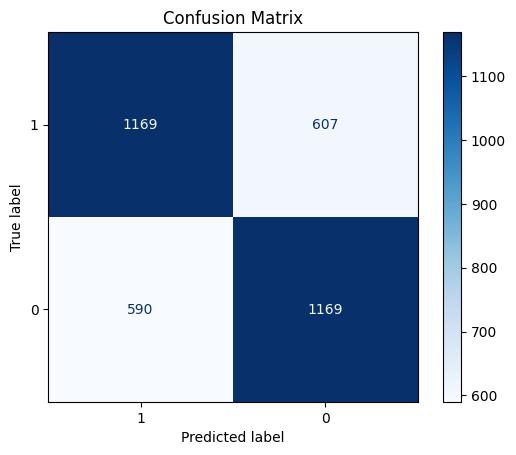

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Computing the confusion matrix
# Mapeia as classes reais e as preditas considerando os labels [1, 0] (Positivo, Negativo)
cm = confusion_matrix(y_test, y_predicted, labels=[1, 0])

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))

# Configura a exibição visual da matriz com gradiente azul
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 0])
disp.plot(cmap=plt.cm.Blues)

# Define o título do gráfico no matplotlib
plt.title('Confusion Matrix')
plt.show()

## Examine the Resulting Model

We can extract and plot the `feature_importances_` inferred from this model to examine which data features are the **most critical for successful prediction** of diabetes in patients.

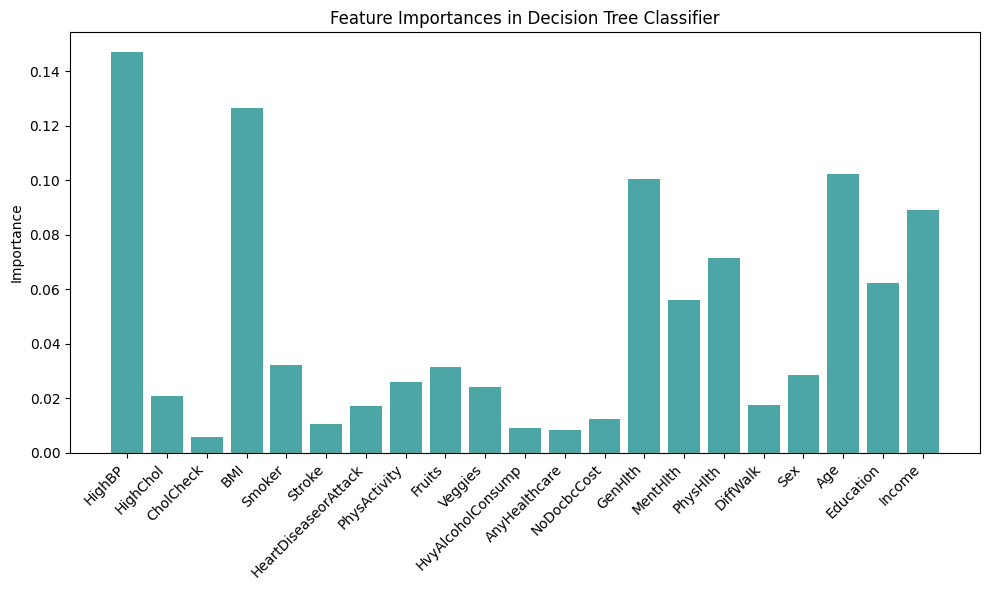

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Retrieving feature importances from the trained decision tree model
feature_importances = dtc_mdl.feature_importances_
feature_names = X_train.columns.to_list()

# Plotting the feature importances
plt.figure(figsize=(10, 6))
y_pos = np.arange(len(feature_names))

# Criação do gráfico de barras
plt.bar(y_pos, feature_importances, align='center', alpha=0.7, color='teal')

# Configuração dos marcadores e legendas do matplotlib
plt.xticks(y_pos, feature_names, rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('Feature Importances in Decision Tree Classifier')

# Ajustar e apresentar o gráfico final
plt.tight_layout()
plt.show()

## Examine the Resulting Tree Structure

Decision trees make splitting decisions on different features at different critical values, so we can visualize the resulting decision logic by plotting or printing that branching tree structure.

In [16]:
# Analisar o tamanho da árvore gerada pelo algoritmo
node_count = dtc_mdl.tree_.node_count
max_depth = dtc_mdl.tree_.max_depth

print(f"The fitted DecisionTreeClassifier model has {node_count} nodes and is up to {max_depth} levels deep.")

The fitted DecisionTreeClassifier model has 38807 nodes and is up to 42 levels deep.


This is a very large decision tree. Printing out the full tree logic allows us to see how vast and sprawling the splits are across our feature sets:

In [18]:
from sklearn.tree import export_text

# Mapeia os nomes das colunas explicativas das features de treino
feature_names = X_train.columns.to_list()

# Exportar a estrutura interna da árvore em formato de árvore de texto estruturada
text_representation = export_text(dtc_mdl, feature_names=feature_names)

# Exibir as primeiras 1000 linhas da árvore para evitar sobrecarga visual no notebook
print(text_representation[:2500])

|--- HighBP <= 0.50
|   |--- GenHlth <= 2.50
|   |   |--- Age <= 9.50
|   |   |   |--- BMI <= 28.50
|   |   |   |   |--- HighChol <= 0.50
|   |   |   |   |   |--- GenHlth <= 1.50
|   |   |   |   |   |   |--- Education <= 3.50
|   |   |   |   |   |   |   |--- Age <= 8.50
|   |   |   |   |   |   |   |   |--- Income <= 1.50
|   |   |   |   |   |   |   |   |   |--- BMI <= 21.50
|   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |   |--- BMI >  21.50
|   |   |   |   |   |   |   |   |   |   |--- Smoker <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |   |   |--- Smoker >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |--- Income >  1.50
|   |   |   |   |   |   |   |   |   |--- PhysActivity <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- Sex <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |   |   |-

### Visualize the decision tree structure

This plot will give you a visual representation of the decision tree structure, helping us to understand how the model makes predictions based on different features and their critical values.

Since the full tree is very large, we can only reasonably visualize a small portion of it at any given time. Here is the **root and first 2 levels**:

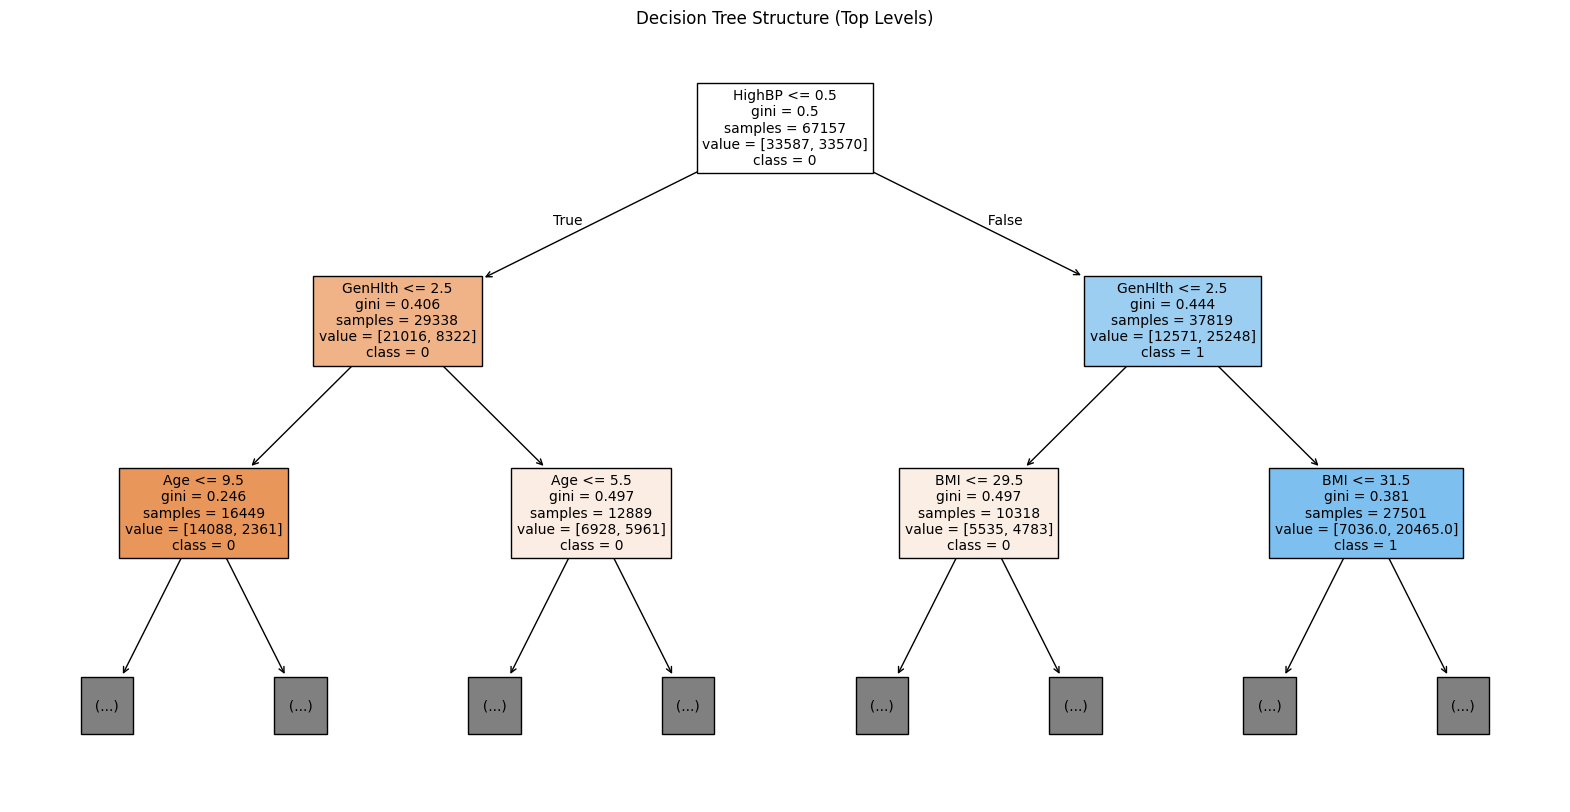

In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configurar o tamanho da figura (amplo para legibilidade)
plt.figure(figsize=(20, 10))

# Mapeia os nomes das features explicativas
feature_names = X_train.columns.to_list()

# Gerar o gráfico da árvore com parâmetros específicos da aula
plot_tree(
    dtc_mdl,                       # O modelo de árvore treinado
    feature_names=feature_names,   # Nomes das variáveis
    max_depth=2,                   # Limita a visualização à raiz e 2 níveis
    class_names=['0', '1'],        # Labels das classes (Não Diabético, Diabético)
    filled=True                    # Colore os nós por classe predominante
)

# Definir o título e exibir o gráfico final
plt.title('Decision Tree Structure (Top Levels)')
plt.show()

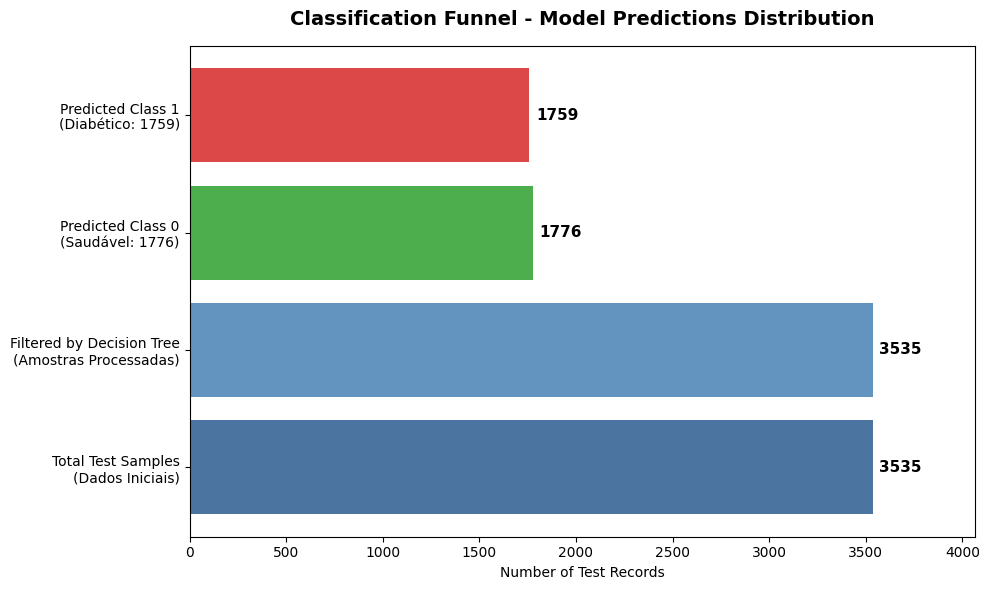

AUDITORIA FINAL DO FUNIL DE CLASSIFICAÇÃO:
 Amostras Totais que entraram no funil: 3535
 └── Classificados como Saudáveis (0):  1776 (Acertou 1169 legítimos)
 └── Classificados como Diabéticos (1): 1759 (Acertou 1169 legítimos)
--------------------------------------------------
 Erros de Classificação (Falsos Alertas): 1197 amostras.


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Obter as amostras que foram classificadas como Saudáveis (0) e Diabéticas (1)
y_test_array = np.array(y_test)
total_test = len(y_test_array)
pred_0 = np.sum(y_predicted == 0)
pred_1 = np.sum(y_predicted == 1)

# Calcular acertos reais (Verdadeiros Positivos e Verdadeiros Negativos)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
tn, fp, fn, tp = cm.ravel()

# 2. Estruturar os níveis do funil para o gráfico
stages = [
    'Total Test Samples\n(Dados Iniciais)',
    f'Filtered by Decision Tree\n(Amostras Processadas)',
    f'Predicted Class 0\n(Saudável: {pred_0})',
    f'Predicted Class 1\n(Diabético: {pred_1})'
]
values = [total_test, total_test, pred_0, pred_1]

# 3. Desenhar o gráfico de barras horizontais em formato de funil
plt.figure(figsize=(10, 6))
bar_colors = ['#2b5c8f', '#4682b4', '#2ca02c', '#d62728']

bars = plt.barh(stages[::-1], values[::-1], color=bar_colors[::-1], align='center', alpha=0.85)

# Adicionar os valores numéricos exatos dentro/ao lado de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + (total_test * 0.01), bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center', ha='left', fontsize=11, fontweight='bold')

plt.title('Classification Funnel - Model Predictions Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Test Records')
plt.xlim(0, total_test * 1.15)  # Espaço para os rótulos numéricos

# Ajustar layout
plt.gca().invert_yaxis()  # Inverter para o funil fluir de cima para baixo
plt.tight_layout()
plt.show()

# 4. Exibir o relatório complementar de auditoria do funil
print("="*50)
print("AUDITORIA FINAL DO FUNIL DE CLASSIFICAÇÃO:")
print("="*50)
print(f" Amostras Totais que entraram no funil: {total_test}")
print(f" └── Classificados como Saudáveis (0):  {pred_0} (Acertou {tn} legítimos)")
print(f" └── Classificados como Diabéticos (1): {pred_1} (Acertou {tp} legítimos)")
print("-"*50)
print(f" Erros de Classificação (Falsos Alertas): {fp + fn} amostras.")
print("="*50)

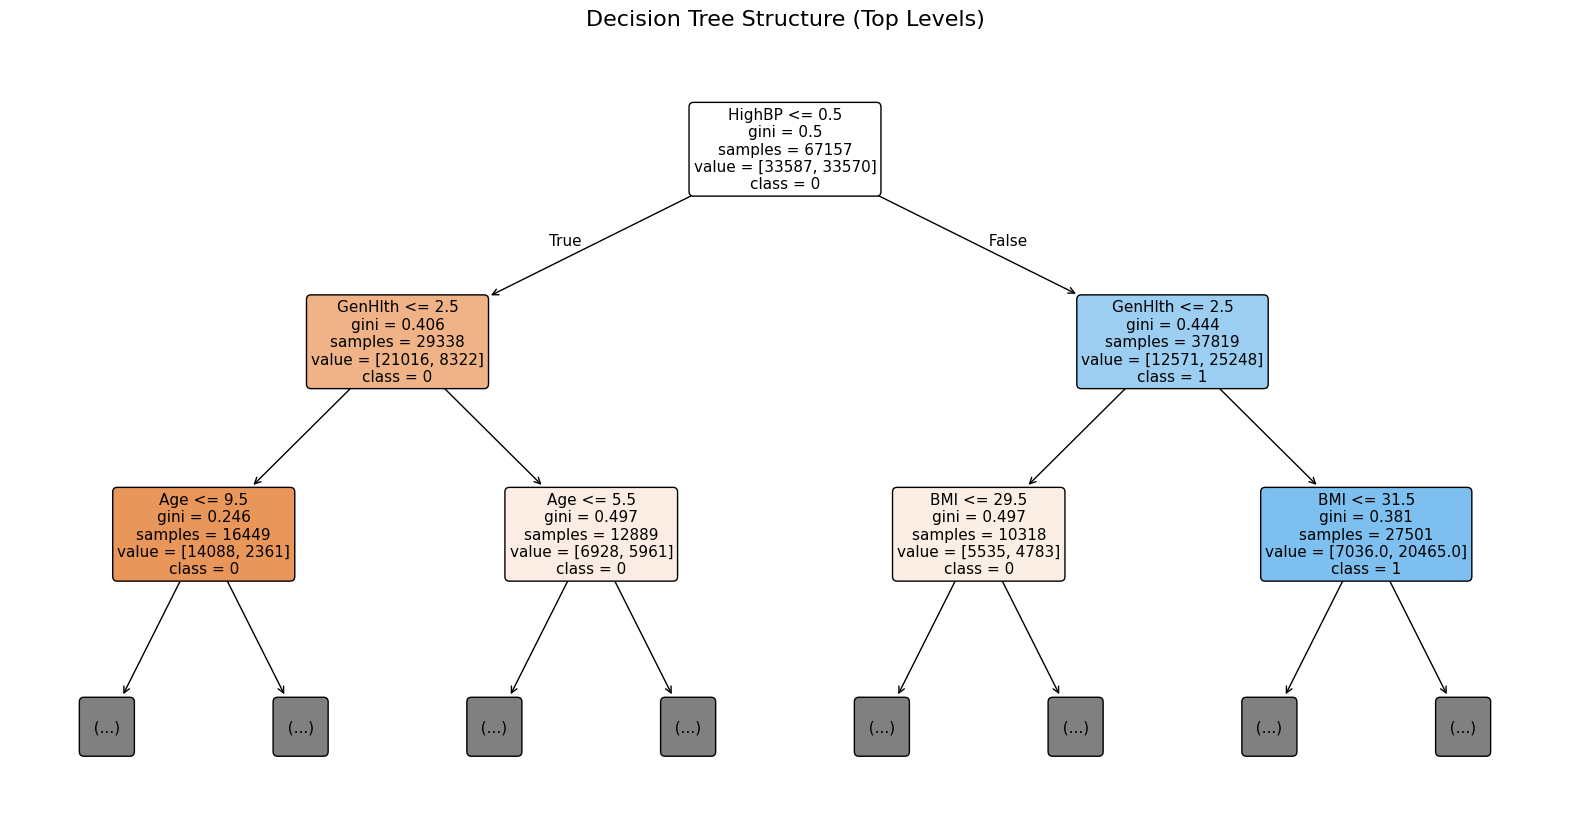

In [21]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Configurar o tamanho da figura (amplo para manter a legibilidade dos nós)
plt.figure(figsize=(20, 10), facecolor='white')

# 2. Mapear os nomes das features explicativas
feature_names = X_train.columns.to_list()

# 3. Gerar o gráfico da árvore
plot_tree(
    dtc_mdl,                       # O modelo de árvore treinado
    feature_names=feature_names,   # Nomes das variáveis do dataset de diabetes
    max_depth=2,                   # Limita a visualização à raiz e aos 2 primeiros níveis
    class_names=['0', '1'],        # Labels das classes (0: Não Diabético, 1: Diabético)
    filled=True,                   # Colore os nós de acordo com a classe predominante
    rounded=True,                  # Deixa as bordas dos nós arredondadas (mais visual)
    fontsize=11                    # Ajusta o tamanho da fonte interna dos nós
)

# 4. Definir o título do gráfico
plt.title('Decision Tree Structure (Top Levels)', fontsize=16, pad=20)

# 5. SALVAR A IMAGEM (Adicione esta linha antes do plt.show)
# O bbox_inches='tight' garante que nenhum nome de variável ou borda saia cortado
plt.savefig('y_predicted_tree.png', dpi=300, bbox_inches='tight')

# 6. Exibir o gráfico final no console do Jupyter
plt.show()

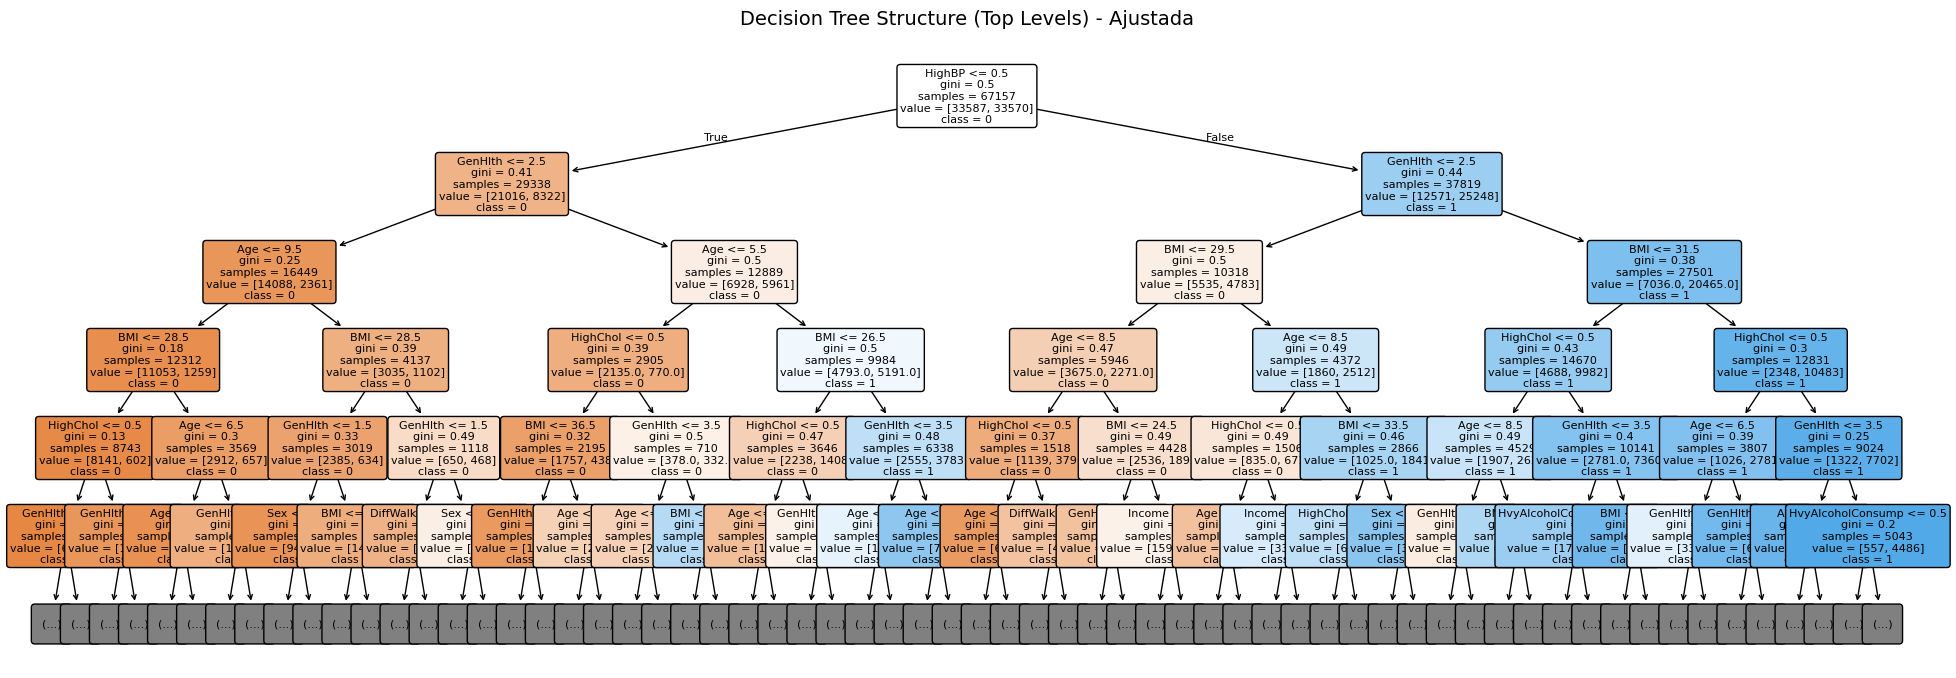

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Aumentamos a largura para 24 e reduzimos a altura para limitar o esmagamento vertical
plt.figure(figsize=(24, 8), facecolor='white')

feature_names = X_train.columns.to_list()

# 2. Gerar o gráfico controlando a dispersão
plot_tree(
    dtc_mdl,
    feature_names=feature_names,
    max_depth=5,
    class_names=['0', '1'],
    filled=True,
    rounded=True,
    fontsize=8,       # <--- Diminuir a fonte impede que o texto saia das caixas
    precision=2       # <--- Limita as casas decimais para encurtar o texto interno
)

plt.title('Decision Tree Structure (Top Levels) - Ajustada', fontsize=14, pad=20)

# O pad adiciona uma margem de segurança extra para não cortar as bordas
plt.savefig('y_predicted_tree_fixed.png', dpi=300, bbox_inches='tight', pad_inches=0.5)
plt.show()